# PERSONAGE Dataset — Exploratory Data Analysis

580 samples: 320 with full OCEAN ground truth, 260 with Extraversion only.
Investigates trait distributions, correlations, and why Extraversion detection is weaker.

In [13]:
import json
import numpy as np
import pandas as pd
from scipy import stats
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 12, "axes.labelsize": 10})

TRAITS = ["O", "C", "E", "A", "N"]
TRAIT_NAMES = {"O": "Openness", "C": "Conscientiousness", "E": "Extraversion", "A": "Agreeableness", "N": "Neuroticism"}
DATA_DIR = Path("../data")

In [14]:
# Load all data
def load_jsonl(path):
    return [json.loads(l) for l in open(path) if l.strip()]

dev = load_jsonl(DATA_DIR / "personage_dev.jsonl")
test = load_jsonl(DATA_DIR / "personage_test.jsonl")
all_data = dev + test

rows = []
for r in all_data:
    gt = r["ground_truth_ocean"]
    row = {
        "id": r["id"],
        "input": r["input"],
        "split": "dev" if r in dev else "test",
        "has_full_ocean": r.get("has_full_ocean", len(gt) == 5),
        "n_traits": len(gt),
        "text_len": len(r["input"]),
        "word_count": len(r["input"].split()),
    }
    for t in TRAITS:
        row[f"gt_{t}"] = gt.get(t, np.nan)
    rows.append(row)

df = pd.DataFrame(rows)
print(f"Total samples: {len(df)}")
print(f"Full OCEAN: {df['has_full_ocean'].sum()}")
print(f"E-only: {(~df['has_full_ocean']).sum()}")
print(f"\nSplit distribution:")
print(df.groupby(["split", "has_full_ocean"]).size().unstack(fill_value=0))

Total samples: 580
Full OCEAN: 320
E-only: 260

Split distribution:
has_full_ocean  False  True 
split                       
dev               132    160
test              128    160


In [15]:
# Per-trait descriptive statistics
trait_stats = []
for t in TRAITS:
    vals = df[f"gt_{t}"].dropna()
    trait_stats.append({
        "Trait": TRAIT_NAMES[t],
        "n": len(vals),
        "mean": vals.mean(),
        "std": vals.std(),
        "min": vals.min(),
        "25%": vals.quantile(0.25),
        "median": vals.median(),
        "75%": vals.quantile(0.75),
        "max": vals.max(),
        "skewness": vals.skew(),
        "kurtosis": vals.kurtosis(),
    })

stats_df = pd.DataFrame(trait_stats).set_index("Trait")
display(stats_df.round(3))

,n,mean,std,min,25%,median,75%,max,skewness,kurtosis
Trait,,,,,,,,,,
Openness,320,-0.051,0.392,-0.917,-0.417,-0.083,0.333,0.750,0.032,-1.113
Conscientiousness,320,0.192,0.380,-0.667,-0.083,0.250,0.521,0.917,-0.306,-0.910
Extraversion,580,0.234,0.470,-1.000,-0.056,0.250,0.611,1.000,-0.522,-0.583
Agreeableness,320,0.230,0.365,-0.917,0.000,0.333,0.500,0.833,-0.633,-0.291
Neuroticism,320,-0.212,0.425,-0.833,-0.583,-0.250,0.083,0.833,0.409,-0.874


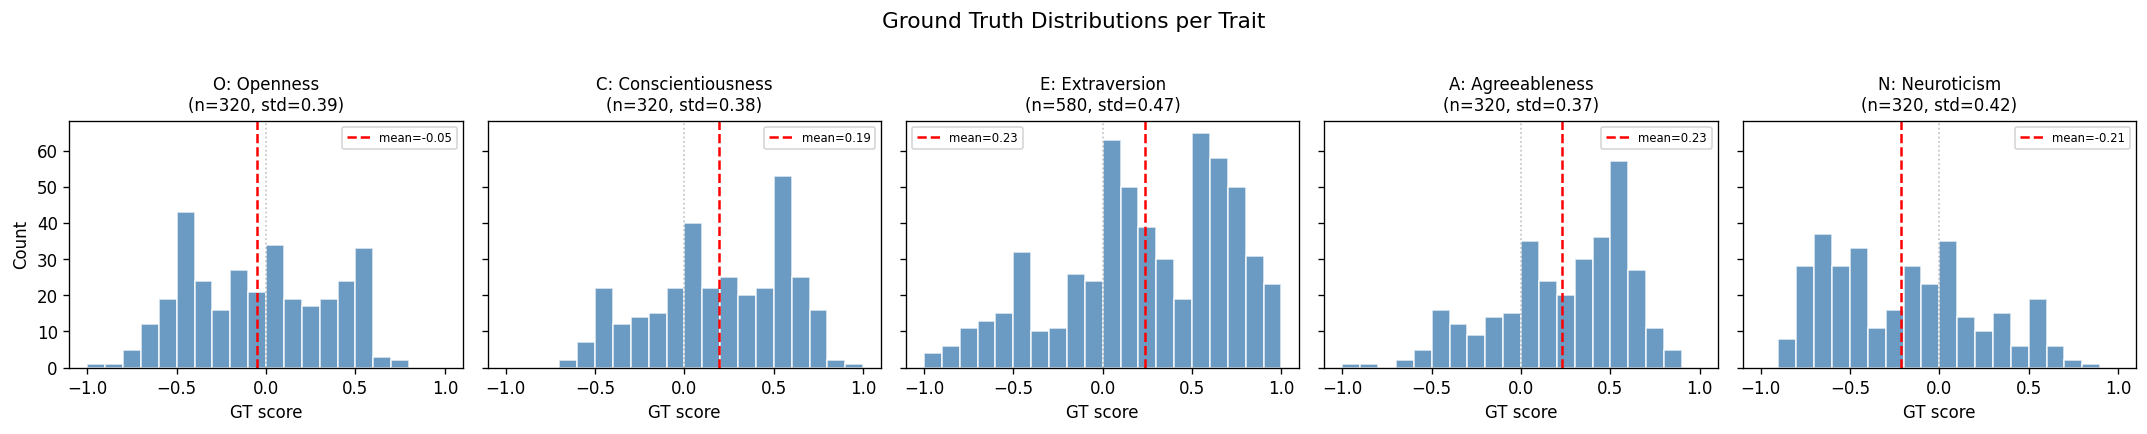

In [16]:
# Trait distributions: histograms
fig, axes = plt.subplots(1, 5, figsize=(18, 3.5), sharey=True)

for ax, t in zip(axes, TRAITS):
    vals = df[f"gt_{t}"].dropna()
    ax.hist(vals, bins=20, range=(-1, 1), color="steelblue", edgecolor="white", alpha=0.8)
    ax.axvline(vals.mean(), color="red", ls="--", lw=1.5, label=f"mean={vals.mean():.2f}")
    ax.axvline(0, color="gray", ls=":", lw=1, alpha=0.5)
    ax.set_title(f"{t}: {TRAIT_NAMES[t]}\n(n={len(vals)}, std={vals.std():.2f})", fontsize=10)
    ax.set_xlabel("GT score")
    ax.legend(fontsize=7)
    ax.set_xlim(-1.1, 1.1)

axes[0].set_ylabel("Count")
fig.suptitle("Ground Truth Distributions per Trait", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

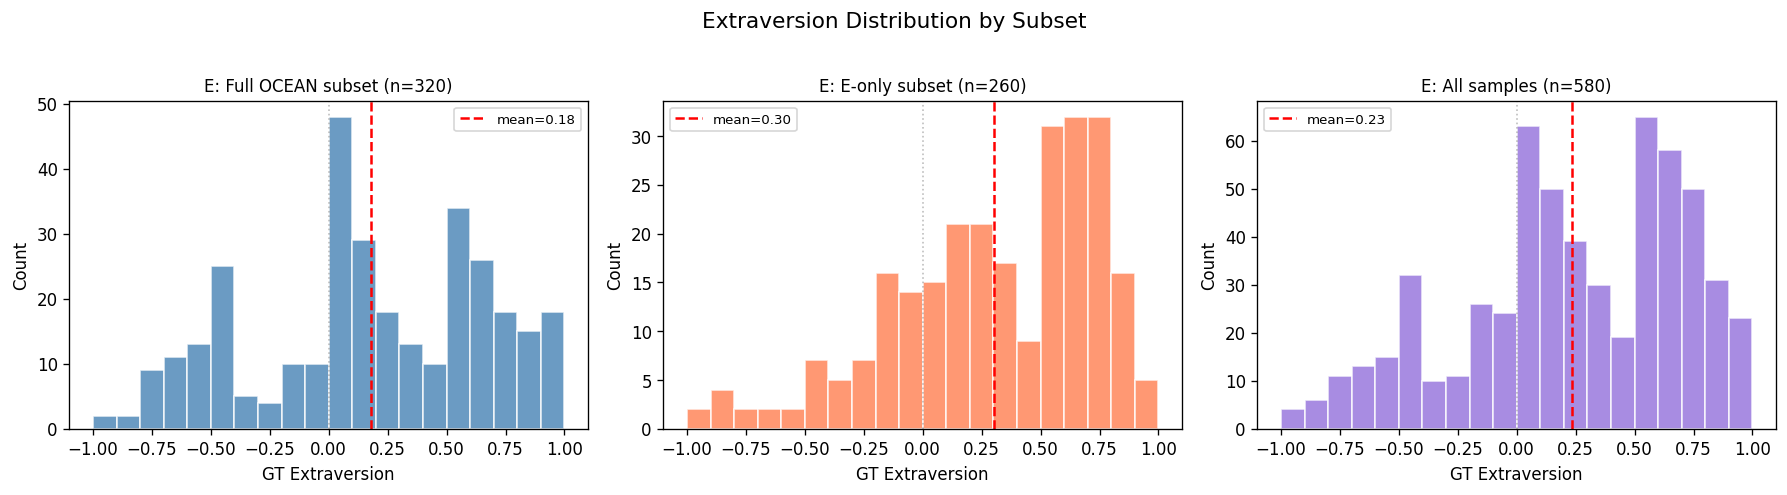

KS test (full vs e-only): KstestResult(statistic=0.17740384615384616, pvalue=0.00020094697424723166, statistic_location=0.25, statistic_sign=1)


In [17]:
# E distribution: full OCEAN vs E-only subsets
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

e_full = df[df["has_full_ocean"]]["gt_E"].dropna()
e_only = df[~df["has_full_ocean"]]["gt_E"].dropna()
e_all = df["gt_E"].dropna()

for ax, vals, title, color in zip(axes,
    [e_full, e_only, e_all],
    [f"E: Full OCEAN subset (n={len(e_full)})", f"E: E-only subset (n={len(e_only)})", f"E: All samples (n={len(e_all)})"],
    ["steelblue", "coral", "mediumpurple"]):
    ax.hist(vals, bins=20, range=(-1, 1), color=color, edgecolor="white", alpha=0.8)
    ax.axvline(vals.mean(), color="red", ls="--", lw=1.5, label=f"mean={vals.mean():.2f}")
    ax.axvline(0, color="gray", ls=":", lw=1, alpha=0.5)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("GT Extraversion")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)
    ax.set_xlim(-1.1, 1.1)

fig.suptitle("Extraversion Distribution by Subset", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"KS test (full vs e-only): {stats.ks_2samp(e_full, e_only)}")

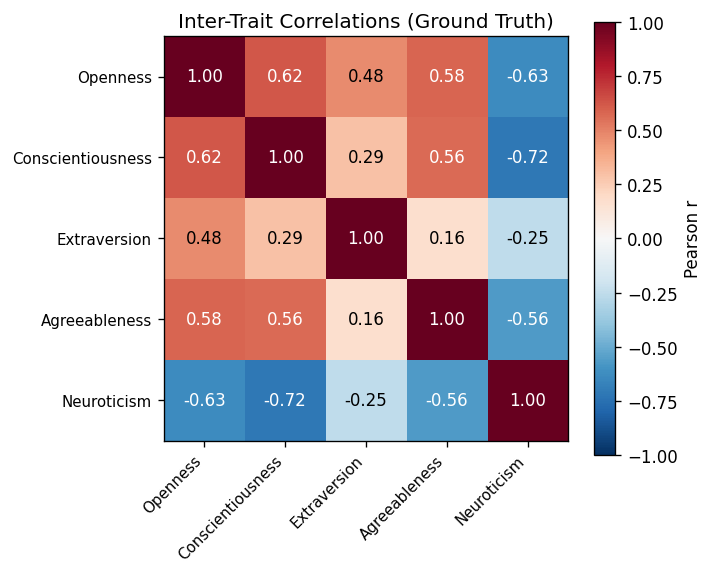

In [18]:
# Inter-trait correlations (full OCEAN subset only)
full = df[df["has_full_ocean"]].copy()
corr_cols = [f"gt_{t}" for t in TRAITS]
corr = full[corr_cols].corr()
corr.columns = TRAITS
corr.index = TRAITS

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(5))
ax.set_xticklabels([TRAIT_NAMES[t] for t in TRAITS], rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(5))
ax.set_yticklabels([TRAIT_NAMES[t] for t in TRAITS], fontsize=9)
for i in range(5):
    for j in range(5):
        ax.text(j, i, f"{corr.values[i,j]:.2f}", ha="center", va="center", fontsize=10,
                color="white" if abs(corr.values[i,j]) > 0.5 else "black")
fig.colorbar(im, label="Pearson r")
ax.set_title("Inter-Trait Correlations (Ground Truth)")
plt.tight_layout()
plt.show()

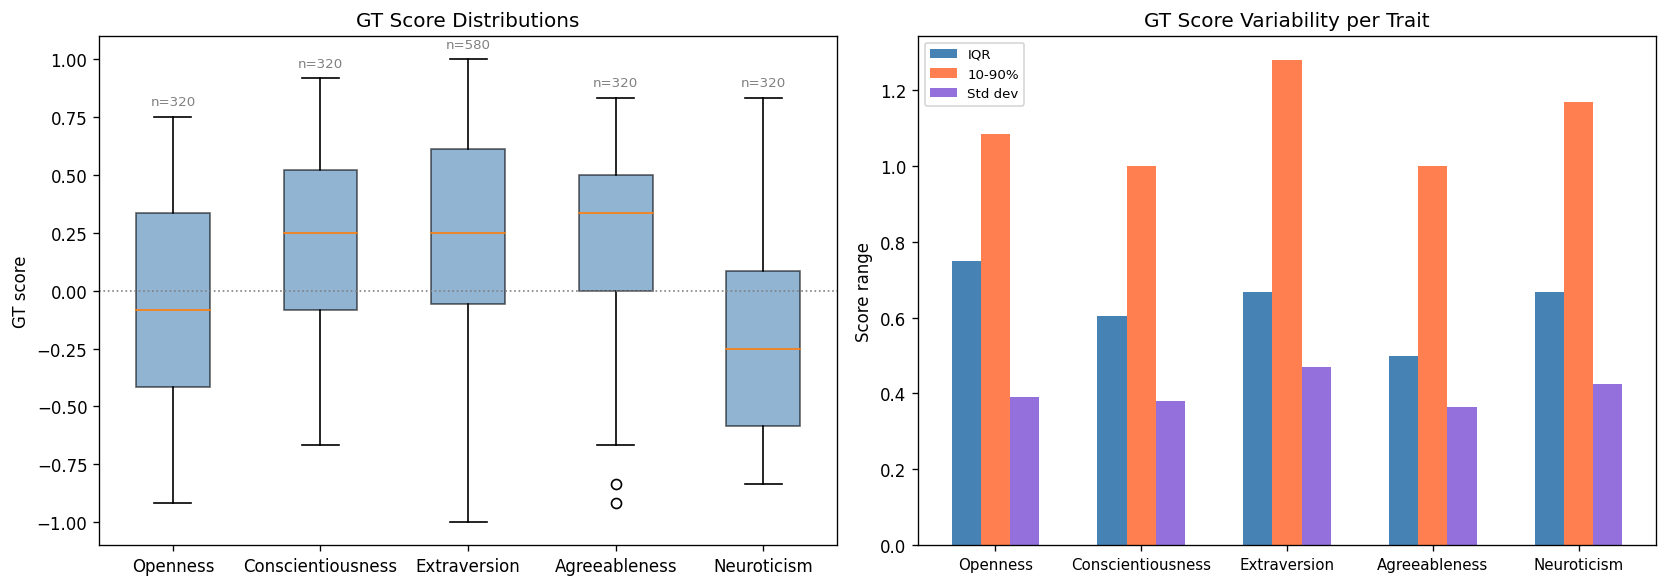

In [19]:
# Trait variance comparison: why is E harder to detect?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot of GT distributions
boxdata = [df[f"gt_{t}"].dropna().values for t in TRAITS]
bp = axes[0].boxplot(boxdata, labels=[TRAIT_NAMES[t] for t in TRAITS], patch_artist=True,
                     boxprops=dict(facecolor="steelblue", alpha=0.6))
axes[0].axhline(0, color="gray", ls=":", lw=1)
axes[0].set_ylabel("GT score")
axes[0].set_title("GT Score Distributions")
for i, t in enumerate(TRAITS):
    v = df[f"gt_{t}"].dropna()
    axes[0].text(i + 1, v.max() + 0.05, f"n={len(v)}", ha="center", fontsize=8, color="gray")

# Effective range: IQR and 10-90 percentile range
ranges = []
for t in TRAITS:
    v = df[f"gt_{t}"].dropna()
    ranges.append({
        "Trait": t,
        "IQR": v.quantile(0.75) - v.quantile(0.25),
        "10-90 range": v.quantile(0.9) - v.quantile(0.1),
        "Full range": v.max() - v.min(),
        "std": v.std(),
    })
range_df = pd.DataFrame(ranges)

x = np.arange(5)
w = 0.2
axes[1].bar(x - w, range_df["IQR"], w, label="IQR", color="steelblue")
axes[1].bar(x, range_df["10-90 range"], w, label="10-90%", color="coral")
axes[1].bar(x + w, range_df["std"], w, label="Std dev", color="mediumpurple")
axes[1].set_xticks(x)
axes[1].set_xticklabels([TRAIT_NAMES[t] for t in TRAITS], fontsize=9)
axes[1].set_ylabel("Score range")
axes[1].set_title("GT Score Variability per Trait")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

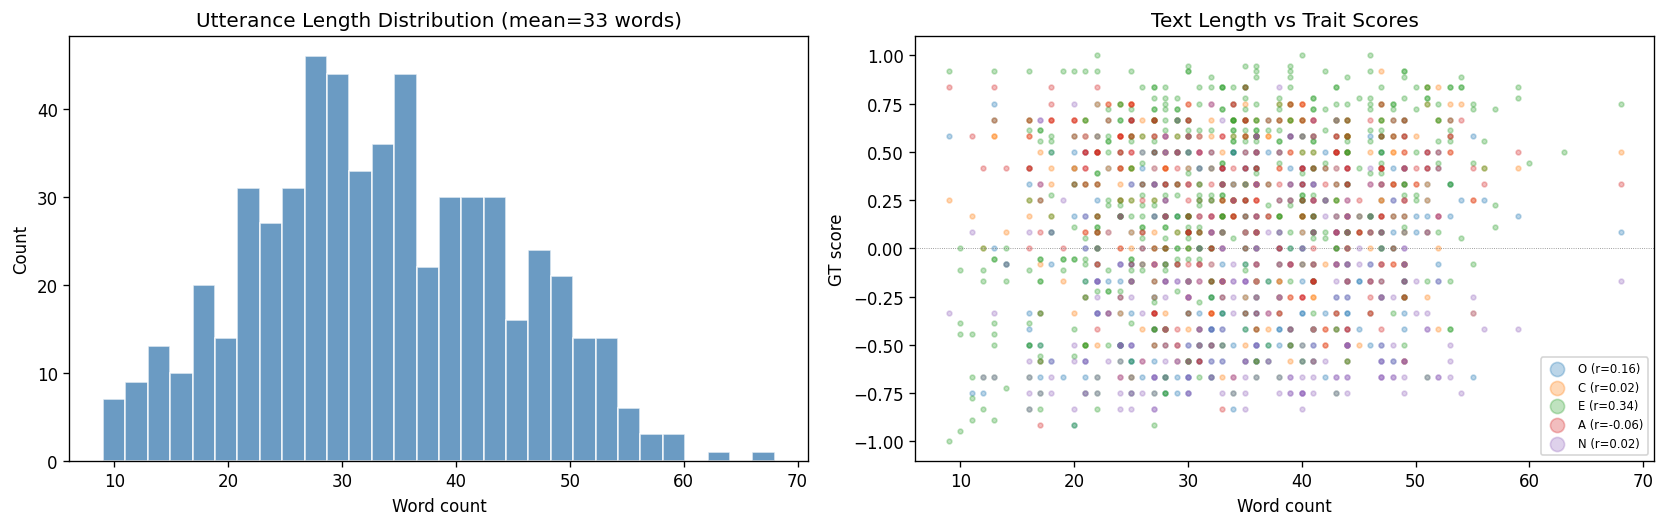

In [20]:
# Text length analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].hist(df["word_count"], bins=30, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].set_xlabel("Word count")
axes[0].set_ylabel("Count")
axes[0].set_title(f"Utterance Length Distribution (mean={df['word_count'].mean():.0f} words)")

# Text length vs trait scores (scatter)
for t in TRAITS:
    has_t = df[f"gt_{t}"].notna()
    r_val, p_val = stats.pearsonr(df.loc[has_t, "word_count"], df.loc[has_t, f"gt_{t}"])
    axes[1].scatter(df.loc[has_t, "word_count"], df.loc[has_t, f"gt_{t}"], s=8, alpha=0.3, label=f"{t} (r={r_val:.2f})")

axes[1].set_xlabel("Word count")
axes[1].set_ylabel("GT score")
axes[1].set_title("Text Length vs Trait Scores")
axes[1].legend(fontsize=7, markerscale=3)
axes[1].axhline(0, color="gray", ls=":", lw=0.5)

plt.tight_layout()
plt.show()

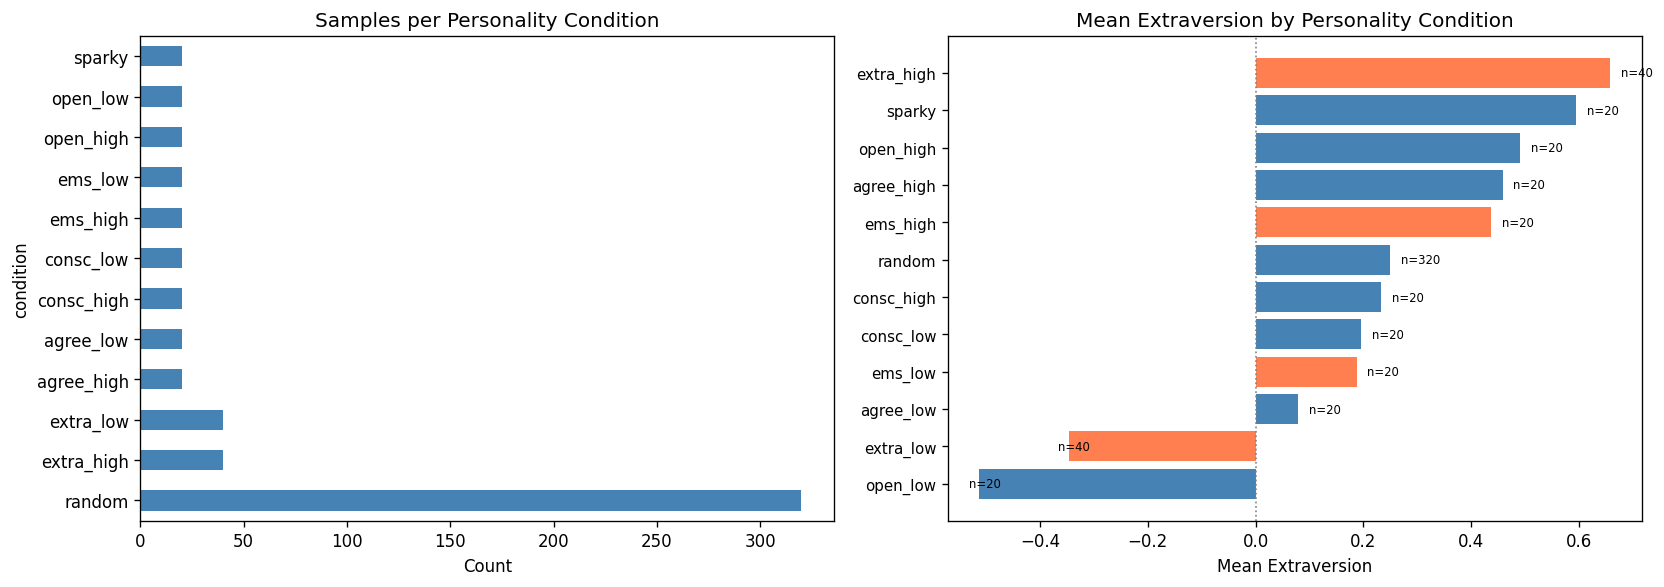

In [21]:
# ID prefix analysis: which personality conditions are in the dataset?
df["condition"] = df["id"].apply(lambda x: x.split("-")[0] if "-" in x else "unknown")
cond_counts = df["condition"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cond_counts.plot.barh(ax=axes[0], color="steelblue")
axes[0].set_xlabel("Count")
axes[0].set_title("Samples per Personality Condition")

# E distribution per condition
conditions = cond_counts.index.tolist()
e_by_cond = []
for cond in conditions:
    vals = df[df["condition"] == cond]["gt_E"].dropna()
    e_by_cond.append({"condition": cond, "n": len(vals), "mean_E": vals.mean(), "std_E": vals.std()})
e_cond_df = pd.DataFrame(e_by_cond).sort_values("mean_E")

colors = ["coral" if "ems" in c or "extra" in c else "steelblue" for c in e_cond_df["condition"]]
axes[1].barh(range(len(e_cond_df)), e_cond_df["mean_E"], color=colors)
axes[1].set_yticks(range(len(e_cond_df)))
axes[1].set_yticklabels(e_cond_df["condition"], fontsize=9)
axes[1].set_xlabel("Mean Extraversion")
axes[1].set_title("Mean Extraversion by Personality Condition")
axes[1].axvline(0, color="gray", ls=":", lw=1)
for i, (_, row) in enumerate(e_cond_df.iterrows()):
    axes[1].text(row["mean_E"] + 0.02 * np.sign(row["mean_E"]), i, f"n={row['n']}", va="center", fontsize=7)

plt.tight_layout()
plt.show()

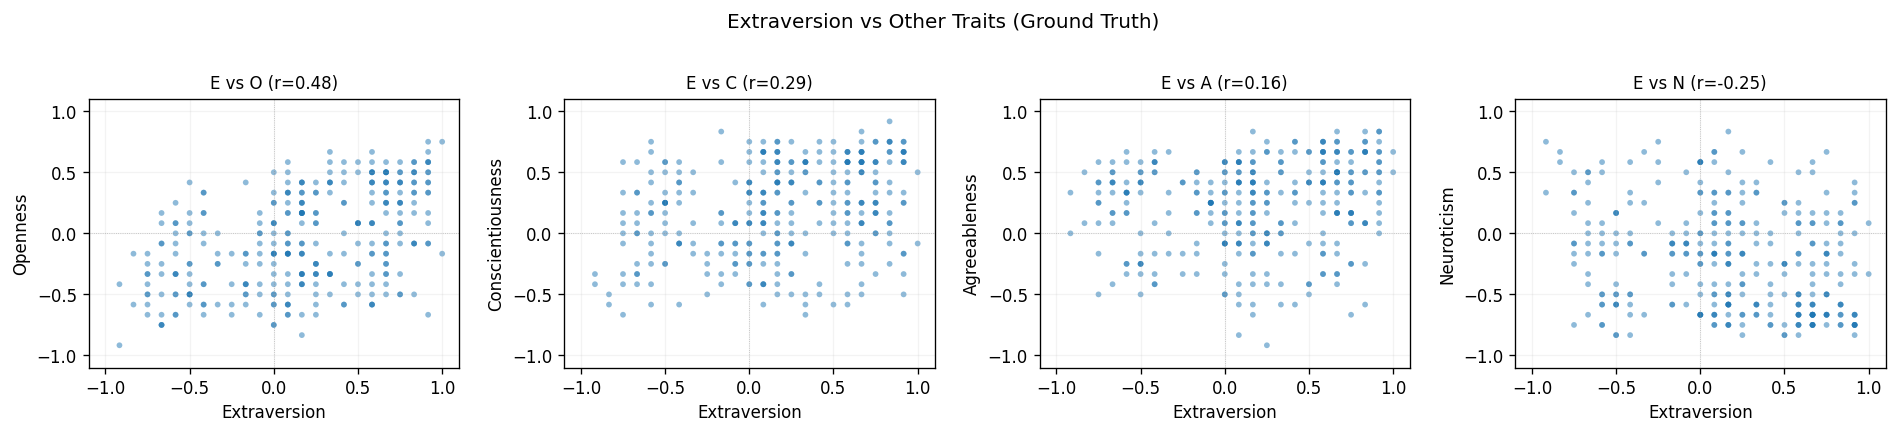

In [22]:
# Pairwise scatter: E vs other traits
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
other = [t for t in TRAITS if t != "E"]

for ax, t in zip(axes, other):
    sub = df.dropna(subset=["gt_E", f"gt_{t}"])
    ax.scatter(sub["gt_E"], sub[f"gt_{t}"], s=12, alpha=0.5, edgecolors="none")
    r_val, _ = stats.pearsonr(sub["gt_E"], sub[f"gt_{t}"])
    ax.set_xlabel("Extraversion")
    ax.set_ylabel(TRAIT_NAMES[t])
    ax.set_title(f"E vs {t} (r={r_val:.2f})", fontsize=10)
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.axhline(0, color="gray", ls=":", lw=0.5, alpha=0.5)
    ax.axvline(0, color="gray", ls=":", lw=0.5, alpha=0.5)
    ax.grid(alpha=0.15)

fig.suptitle("Extraversion vs Other Traits (Ground Truth)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

Loaded 80 predictions


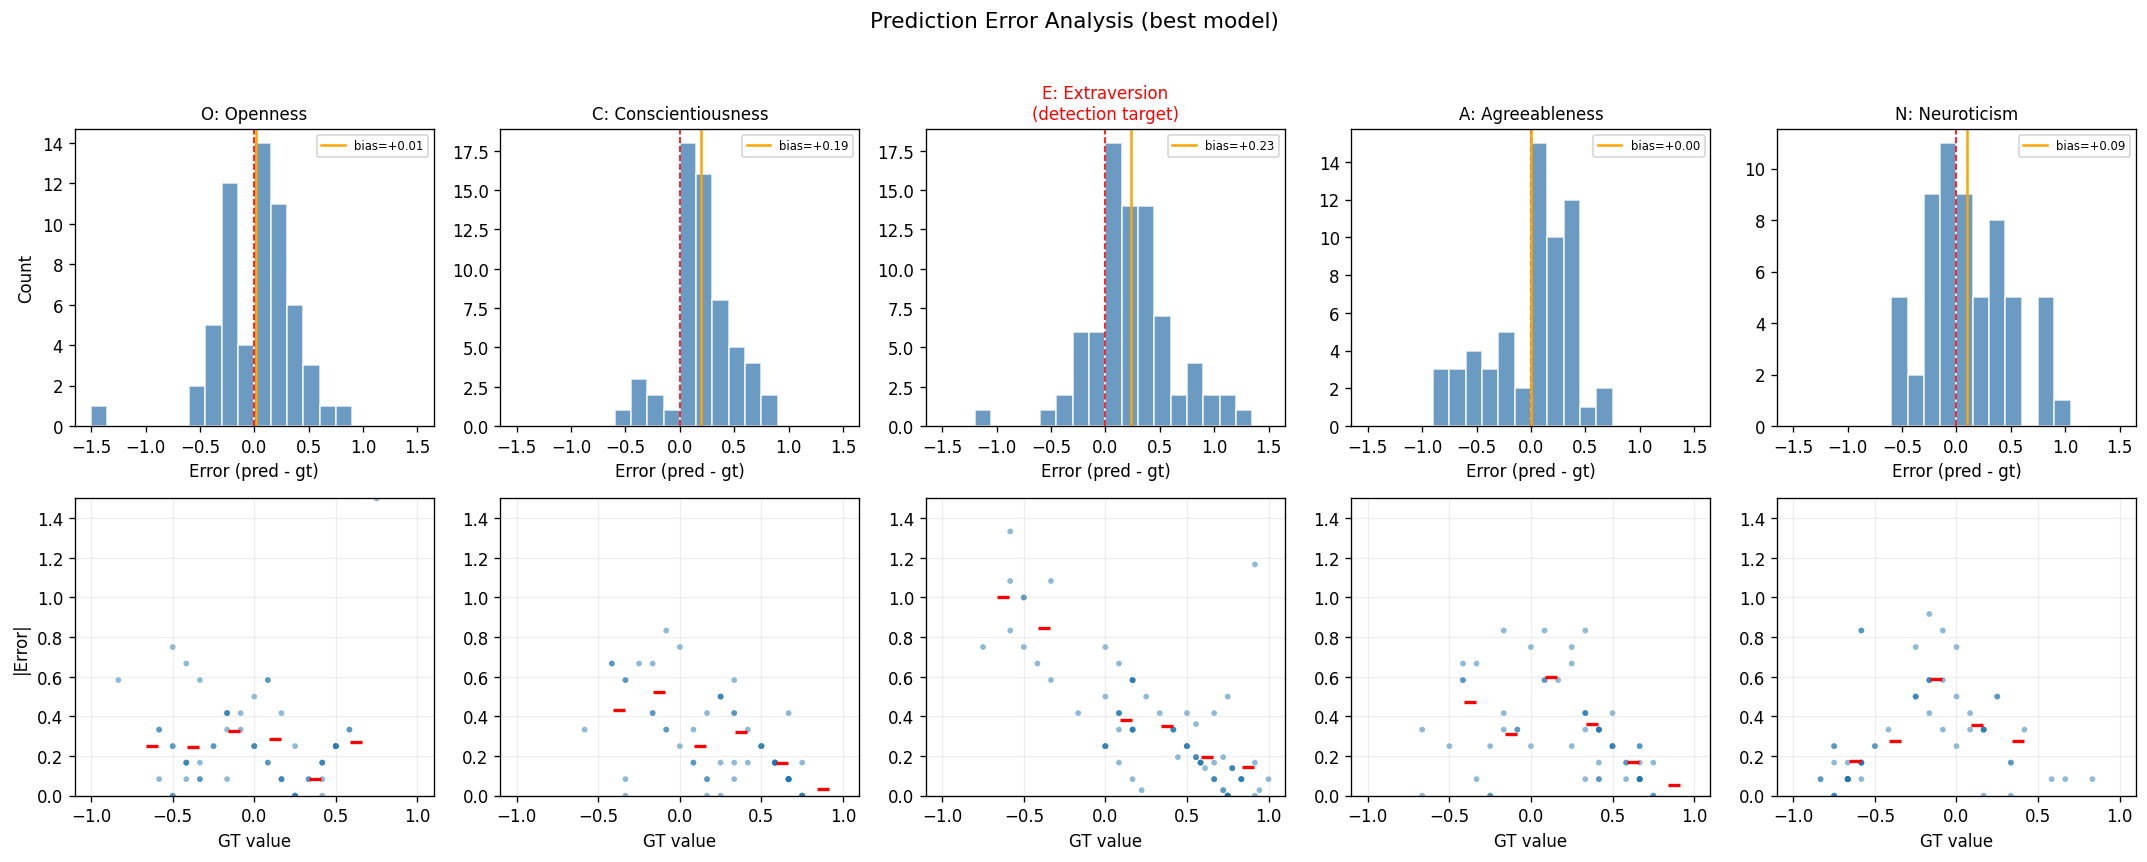

In [23]:
# Detection difficulty analysis: compare best-model predictions vs GT
# Load best model results from Phase 2
from collections import defaultdict

best_files = sorted(Path("../results").glob("benchmark_llama-3.3-70b_*.jsonl"))
if not best_files:
    best_files = sorted(Path("../results").glob("harness_trait_first_s11_t03*.jsonl"))

pred_rows = []
for fp in best_files:
    for line in open(fp):
        r = json.loads(line.strip())
        if r.get("detected_ocean"):
            pred_rows.append(r)

print(f"Loaded {len(pred_rows)} predictions")

# Per-trait error analysis
fig, axes = plt.subplots(2, 5, figsize=(18, 7))

for col, t in enumerate(TRAITS):
    pairs = [(r["detected_ocean"][t], r["ground_truth_ocean"][t])
             for r in pred_rows if t in r.get("ground_truth_ocean", {})]
    if not pairs:
        continue
    pred, gt = np.array([p[0] for p in pairs]), np.array([p[1] for p in pairs])
    errors = pred - gt
    abs_errors = np.abs(errors)

    # Top: error distribution
    ax = axes[0, col]
    ax.hist(errors, bins=20, range=(-1.5, 1.5), color="steelblue", edgecolor="white", alpha=0.8)
    ax.axvline(0, color="red", ls="--", lw=1)
    ax.axvline(errors.mean(), color="orange", ls="-", lw=1.5, label=f"bias={errors.mean():+.2f}")
    ax.set_title(f"{t}: {TRAIT_NAMES[t]}", fontsize=10)
    ax.set_xlabel("Error (pred - gt)")
    ax.legend(fontsize=7)
    if col == 0:
        ax.set_ylabel("Count")

    # Bottom: absolute error vs GT value
    ax2 = axes[1, col]
    ax2.scatter(gt, abs_errors, s=12, alpha=0.5, edgecolors="none")
    # bin means
    bins = np.linspace(-1, 1, 9)
    bin_idx = np.digitize(gt, bins)
    for b in range(1, len(bins)):
        mask = bin_idx == b
        if mask.sum() >= 3:
            ax2.scatter(bins[b-1:b+1].mean(), abs_errors[mask].mean(), s=60, color="red", zorder=5, marker="_", linewidths=2)
    ax2.set_xlabel("GT value")
    if col == 0:
        ax2.set_ylabel("|Error|")
    ax2.set_xlim(-1.1, 1.1)
    ax2.set_ylim(0, 1.5)
    ax2.grid(alpha=0.2)

axes[0, 2].set_title(f"E: {TRAIT_NAMES['E']}\n(detection target)", fontsize=10, color="red")
fig.suptitle("Prediction Error Analysis (best model)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [24]:
# Summary: why is E detection weaker?
print("=" * 65)
print("  WHY IS EXTRAVERSION DETECTION WEAKER?")
print("=" * 65)

# 1. Sample size
print("\n1. Sample size (NOT the cause):")
for t in TRAITS:
    n = df[f"gt_{t}"].notna().sum()
    marker = " <-- most data" if t == "E" else ""
    print(f"   {TRAIT_NAMES[t]:<20s} n={n:>4}{marker}")

# 2. GT variance
print("\n2. Ground truth variability:")
for t in TRAITS:
    v = df[f"gt_{t}"].dropna()
    print(f"   {TRAIT_NAMES[t]:<20s} std={v.std():.3f}  IQR={v.quantile(0.75)-v.quantile(0.25):.3f}")

# 3. Skewness
print("\n3. Distribution skewness:")
for t in TRAITS:
    v = df[f"gt_{t}"].dropna()
    print(f"   {TRAIT_NAMES[t]:<20s} skew={v.skew():+.3f}  mean={v.mean():+.3f}")

# 4. E vs A conflation
if df.dropna(subset=["gt_E", "gt_A"]).shape[0] > 10:
    r_ea, _ = stats.pearsonr(df.dropna(subset=["gt_E", "gt_A"])["gt_E"], df.dropna(subset=["gt_E", "gt_A"])["gt_A"])
    print(f"\n4. E-A ground truth correlation: r={r_ea:.3f}")
    print("   (High correlation makes it harder for models to distinguish E from A)")

print("\n" + "=" * 65)
print("  CONCLUSION")
print("=" * 65)
print("  E has the MOST data (580 vs 320), so sample size is not the issue.")
print("  Likely causes:")
print("  - E is inherently harder to judge from text style alone")
print("  - Friendly/warm phrasing conflated with E (actually A)")
print("  - PERSONAGE E manipulation may be subtler than A/N")
print("=" * 65)

  WHY IS EXTRAVERSION DETECTION WEAKER?

1. Sample size (NOT the cause):
   Openness             n= 320
   Conscientiousness    n= 320
   Extraversion         n= 580 <-- most data
   Agreeableness        n= 320
   Neuroticism          n= 320

2. Ground truth variability:
   Openness             std=0.392  IQR=0.750
   Conscientiousness    std=0.380  IQR=0.604
   Extraversion         std=0.470  IQR=0.667
   Agreeableness        std=0.365  IQR=0.500
   Neuroticism          std=0.425  IQR=0.667

3. Distribution skewness:
   Openness             skew=+0.032  mean=-0.051
   Conscientiousness    skew=-0.306  mean=+0.192
   Extraversion         skew=-0.522  mean=+0.234
   Agreeableness        skew=-0.633  mean=+0.230
   Neuroticism          skew=+0.409  mean=-0.212

4. E-A ground truth correlation: r=0.165
   (High correlation makes it harder for models to distinguish E from A)

  CONCLUSION
  E has the MOST data (580 vs 320), so sample size is not the issue.
  Likely causes:
  - E is inheren

## Deep Dive: Why is Extraversion Detection Weaker?

The sections below investigate three hypotheses:
1. **Positive bias on low-E text** — the model systematically over-predicts E for introverted utterances
2. **Text-length confound** — longer utterances have higher E, and the model may use length as a proxy
3. **Distributional shift** — the E-only subset has a significantly different E distribution than the full-OCEAN subset

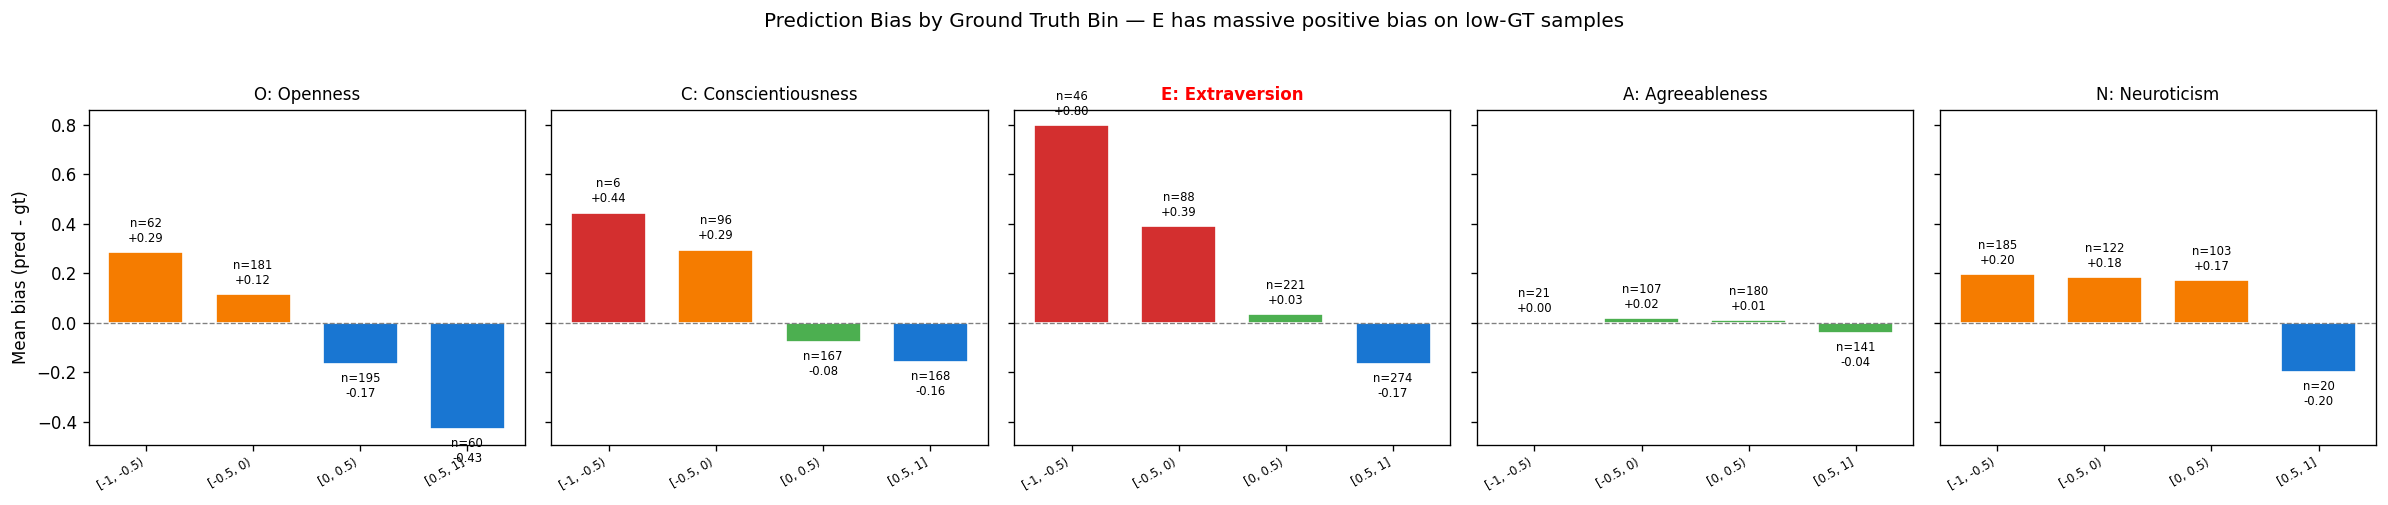

In [25]:
# --- Finding 1: E prediction bias by GT bin ---
pred_rows_all = []
for fp in sorted(Path("../results").glob("benchmark_*.jsonl")):
    for line in open(fp):
        r = json.loads(line.strip())
        if r.get("detected_ocean"):
            pred_rows_all.append(r)
if not pred_rows_all:
    for fp in sorted(Path("../results").glob("harness_*.jsonl")):
        for line in open(fp):
            r = json.loads(line.strip())
            if r.get("detected_ocean"):
                pred_rows_all.append(r)

# Aggregate per-trait bias by GT bin
bins_edges = [(-1.0, -0.5), (-0.5, 0.0), (0.0, 0.5), (0.5, 1.0)]
bin_labels = ["[-1, -0.5)", "[-0.5, 0)", "[0, 0.5)", "[0.5, 1]"]

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)

for ax, t in zip(axes, TRAITS):
    pairs = [(r["detected_ocean"][t], r["ground_truth_ocean"][t])
             for r in pred_rows_all if t in r.get("ground_truth_ocean", {}) and t in r.get("detected_ocean", {})]
    if not pairs:
        continue
    pred_arr = np.array([p[0] for p in pairs])
    gt_arr = np.array([p[1] for p in pairs])

    biases, counts = [], []
    for lo, hi in bins_edges:
        mask = (gt_arr >= lo) & (gt_arr < hi + 0.01)
        if mask.sum() >= 2:
            biases.append((pred_arr[mask] - gt_arr[mask]).mean())
            counts.append(mask.sum())
        else:
            biases.append(0)
            counts.append(0)

    colors = ["#d32f2f" if b > 0.3 else "#f57c00" if b > 0.1 else "#4caf50" if abs(b) <= 0.1 else "#1976d2" for b in biases]
    bars = ax.bar(range(4), biases, color=colors, edgecolor="white", width=0.7)
    ax.set_xticks(range(4))
    ax.set_xticklabels(bin_labels, fontsize=7, rotation=30, ha="right")
    ax.axhline(0, color="gray", ls="--", lw=0.8)
    ax.set_title(f"{t}: {TRAIT_NAMES[t]}", fontsize=10, fontweight="bold" if t == "E" else "normal",
                 color="red" if t == "E" else "black")
    for i, (b, n) in enumerate(zip(biases, counts)):
        ax.text(i, b + 0.03 * np.sign(b), f"n={n}\n{b:+.2f}", ha="center", fontsize=7, va="bottom" if b >= 0 else "top")

axes[0].set_ylabel("Mean bias (pred - gt)")
fig.suptitle("Prediction Bias by Ground Truth Bin — E has massive positive bias on low-GT samples", fontsize=12, y=1.04)
plt.tight_layout()
plt.show()

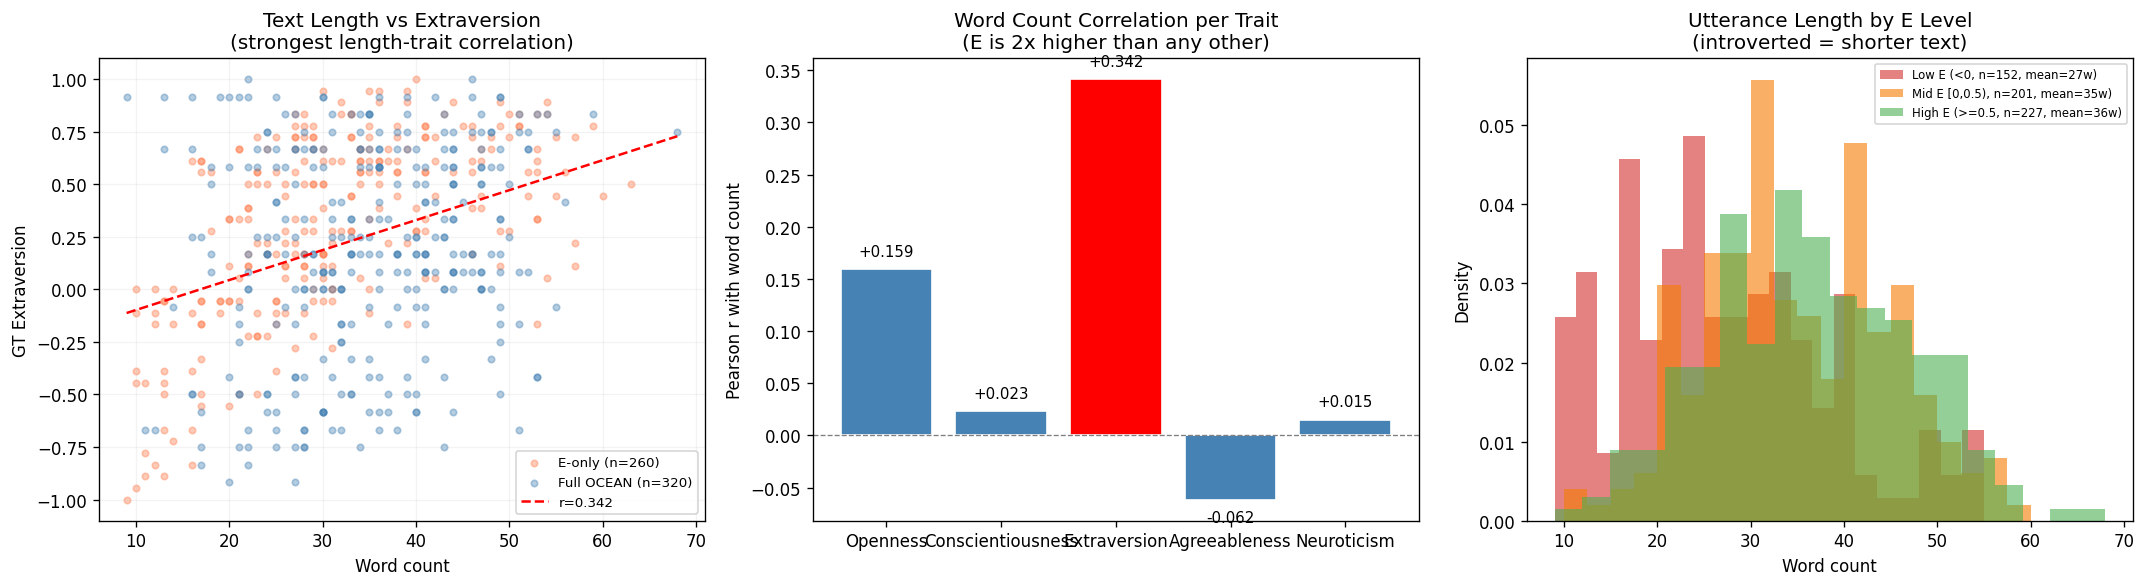


Length-E confound: introverted utterances average 27 words vs 36 for extraverted
If model uses verbosity as proxy for E, it will systematically over-predict E on short/terse text


In [26]:
# --- Finding 2: Text-length confound with Extraversion ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# a) Scatter: word count vs E, colored by subset
full_mask = df["has_full_ocean"]
ax = axes[0]
ax.scatter(df.loc[~full_mask, "word_count"], df.loc[~full_mask, "gt_E"], s=15, alpha=0.4, c="coral", label=f"E-only (n={(~full_mask).sum()})")
ax.scatter(df.loc[full_mask, "word_count"], df.loc[full_mask, "gt_E"], s=15, alpha=0.4, c="steelblue", label=f"Full OCEAN (n={full_mask.sum()})")
r_all, _ = stats.pearsonr(df["word_count"], df["gt_E"])
z = np.polyfit(df["word_count"], df["gt_E"], 1)
x_line = np.linspace(df["word_count"].min(), df["word_count"].max(), 100)
ax.plot(x_line, np.polyval(z, x_line), "r--", lw=1.5, label=f"r={r_all:.3f}")
ax.set_xlabel("Word count")
ax.set_ylabel("GT Extraversion")
ax.set_title("Text Length vs Extraversion\n(strongest length-trait correlation)")
ax.legend(fontsize=8)
ax.grid(alpha=0.15)

# b) Bar chart: length-trait correlations
ax = axes[1]
r_vals = []
for t in TRAITS:
    sub = df.dropna(subset=[f"gt_{t}"])
    r_val, p_val = stats.pearsonr(sub["word_count"], sub[f"gt_{t}"])
    r_vals.append(r_val)
colors = ["red" if t == "E" else "steelblue" for t in TRAITS]
bars = ax.bar([TRAIT_NAMES[t] for t in TRAITS], r_vals, color=colors, edgecolor="white")
ax.axhline(0, color="gray", ls="--", lw=0.8)
for bar, rv in zip(bars, r_vals):
    ax.text(bar.get_x() + bar.get_width()/2, rv + 0.01 * np.sign(rv), f"{rv:+.3f}", ha="center", fontsize=9, va="bottom" if rv >= 0 else "top")
ax.set_ylabel("Pearson r with word count")
ax.set_title("Word Count Correlation per Trait\n(E is 2x higher than any other)")

# c) Word count distribution: low-E vs high-E
ax = axes[2]
e_low = df[df["gt_E"] < 0]["word_count"]
e_high = df[df["gt_E"] >= 0.5]["word_count"]
e_mid = df[(df["gt_E"] >= 0) & (df["gt_E"] < 0.5)]["word_count"]
ax.hist(e_low, bins=20, alpha=0.6, color="#d32f2f", label=f"Low E (<0, n={len(e_low)}, mean={e_low.mean():.0f}w)", density=True)
ax.hist(e_mid, bins=20, alpha=0.6, color="#f57c00", label=f"Mid E [0,0.5), n={len(e_mid)}, mean={e_mid.mean():.0f}w)", density=True)
ax.hist(e_high, bins=20, alpha=0.6, color="#4caf50", label=f"High E (>=0.5, n={len(e_high)}, mean={e_high.mean():.0f}w)", density=True)
ax.set_xlabel("Word count")
ax.set_ylabel("Density")
ax.set_title("Utterance Length by E Level\n(introverted = shorter text)")
ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

print(f"\nLength-E confound: introverted utterances average {e_low.mean():.0f} words vs {e_high.mean():.0f} for extraverted")
print(f"If model uses verbosity as proxy for E, it will systematically over-predict E on short/terse text")

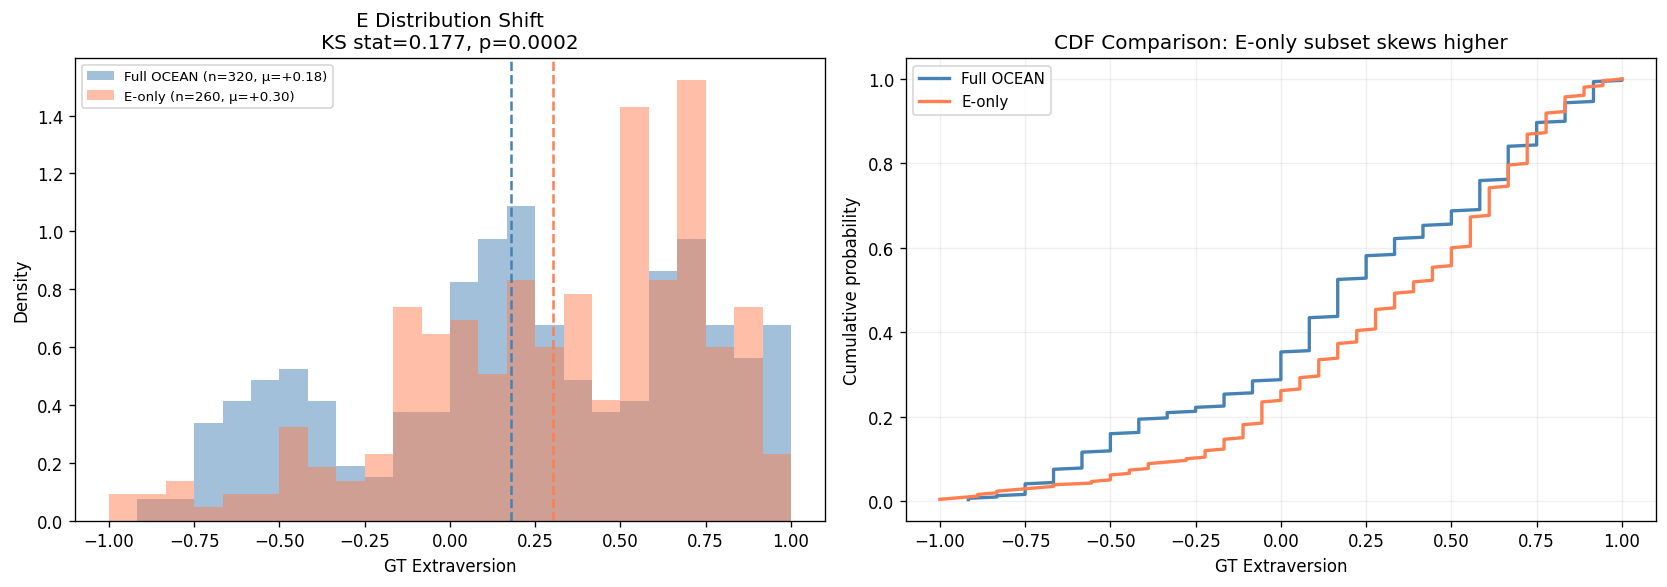

KS test:           stat=0.177, p=0.0002 ***
Mann-Whitney U:    stat=35852, p=0.0042 **

E-only subset has significantly higher E (mean diff = +0.125)
This means the merged dataset over-represents high-E samples


In [27]:
# --- Finding 3: E-only subset distributional shift ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# a) Overlaid density plots
ax = axes[0]
e_full_v = df[df["has_full_ocean"]]["gt_E"].dropna()
e_only_v = df[~df["has_full_ocean"]]["gt_E"].dropna()
bins_h = np.linspace(-1, 1, 25)
ax.hist(e_full_v, bins=bins_h, density=True, alpha=0.5, color="steelblue", label=f"Full OCEAN (n={len(e_full_v)}, μ={e_full_v.mean():+.2f})")
ax.hist(e_only_v, bins=bins_h, density=True, alpha=0.5, color="coral", label=f"E-only (n={len(e_only_v)}, μ={e_only_v.mean():+.2f})")
ax.axvline(e_full_v.mean(), color="steelblue", ls="--", lw=1.5)
ax.axvline(e_only_v.mean(), color="coral", ls="--", lw=1.5)
ks_stat, ks_p = stats.ks_2samp(e_full_v, e_only_v)
ax.set_title(f"E Distribution Shift\nKS stat={ks_stat:.3f}, p={ks_p:.4f}")
ax.set_xlabel("GT Extraversion")
ax.set_ylabel("Density")
ax.legend(fontsize=8)

# b) CDF comparison
ax = axes[1]
e_full_sorted = np.sort(e_full_v)
e_only_sorted = np.sort(e_only_v)
ax.plot(e_full_sorted, np.arange(1, len(e_full_sorted)+1)/len(e_full_sorted), color="steelblue", lw=2, label="Full OCEAN")
ax.plot(e_only_sorted, np.arange(1, len(e_only_sorted)+1)/len(e_only_sorted), color="coral", lw=2, label="E-only")
ax.set_xlabel("GT Extraversion")
ax.set_ylabel("Cumulative probability")
ax.set_title("CDF Comparison: E-only subset skews higher")
ax.legend(fontsize=9)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# Statistical tests
mw_stat, mw_p = stats.mannwhitneyu(e_full_v, e_only_v, alternative="two-sided")
print(f"KS test:           stat={ks_stat:.3f}, p={ks_p:.4f} {'***' if ks_p < 0.001 else '**' if ks_p < 0.01 else '*' if ks_p < 0.05 else 'ns'}")
print(f"Mann-Whitney U:    stat={mw_stat:.0f}, p={mw_p:.4f} {'***' if mw_p < 0.001 else '**' if mw_p < 0.01 else '*' if mw_p < 0.05 else 'ns'}")
print(f"\nE-only subset has significantly higher E (mean diff = {e_only_v.mean() - e_full_v.mean():+.3f})")
print(f"This means the merged dataset over-represents high-E samples")

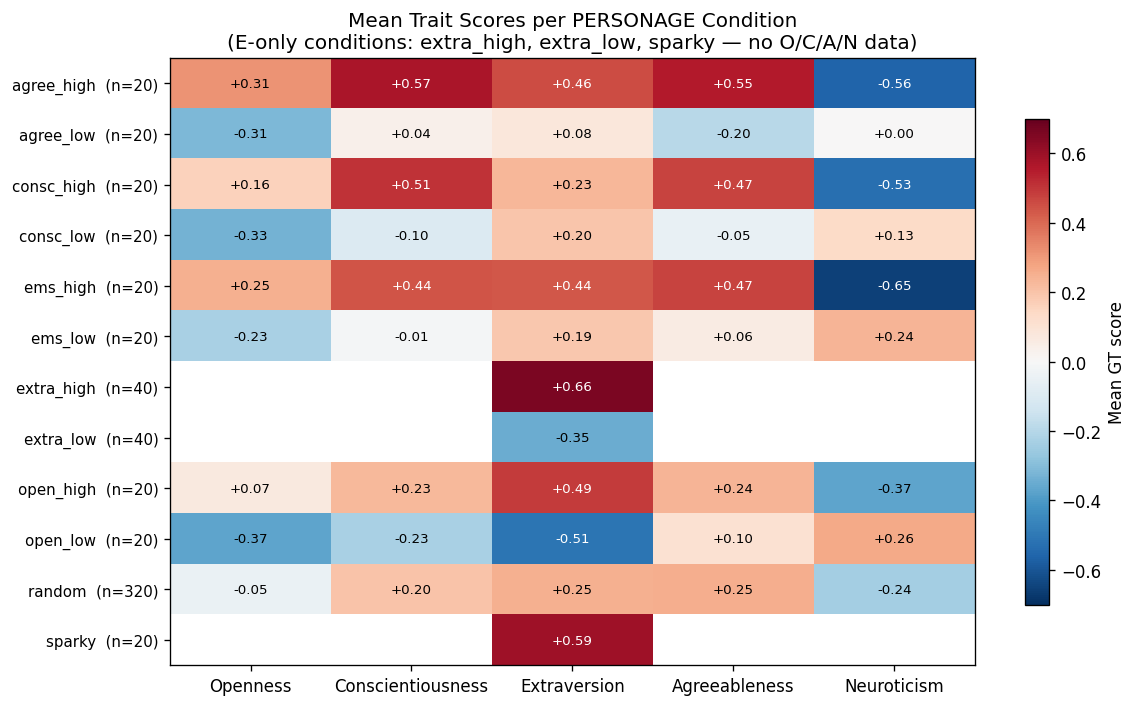

In [28]:
# --- Finding 4: Per-condition trait profiles (radar/heatmap) ---
df["condition"] = df["id"].apply(lambda x: x.split("-")[0] if "-" in x else "unknown")
conditions = sorted(df["condition"].unique())

# Heatmap: mean trait score per condition
cond_means = []
for cond in conditions:
    sub = df[df["condition"] == cond]
    row = {"condition": cond, "n": len(sub)}
    for t in TRAITS:
        vals = sub[f"gt_{t}"].dropna()
        row[t] = vals.mean() if len(vals) > 0 else np.nan
    cond_means.append(row)
cond_df = pd.DataFrame(cond_means).set_index("condition")

fig, ax = plt.subplots(figsize=(10, 6))
data = cond_df[TRAITS].values
im = ax.imshow(data, cmap="RdBu_r", vmin=-0.7, vmax=0.7, aspect="auto")
ax.set_xticks(range(5))
ax.set_xticklabels([TRAIT_NAMES[t] for t in TRAITS], fontsize=10)
ax.set_yticks(range(len(conditions)))
ax.set_yticklabels([f"{c}  (n={cond_df.loc[c, 'n']:.0f})" for c in conditions], fontsize=9)
for i in range(len(conditions)):
    for j in range(5):
        v = data[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:+.2f}", ha="center", va="center", fontsize=8,
                    color="white" if abs(v) > 0.4 else "black")
fig.colorbar(im, label="Mean GT score", shrink=0.8)
ax.set_title("Mean Trait Scores per PERSONAGE Condition\n(E-only conditions: extra_high, extra_low, sparky — no O/C/A/N data)")
plt.tight_layout()
plt.show()

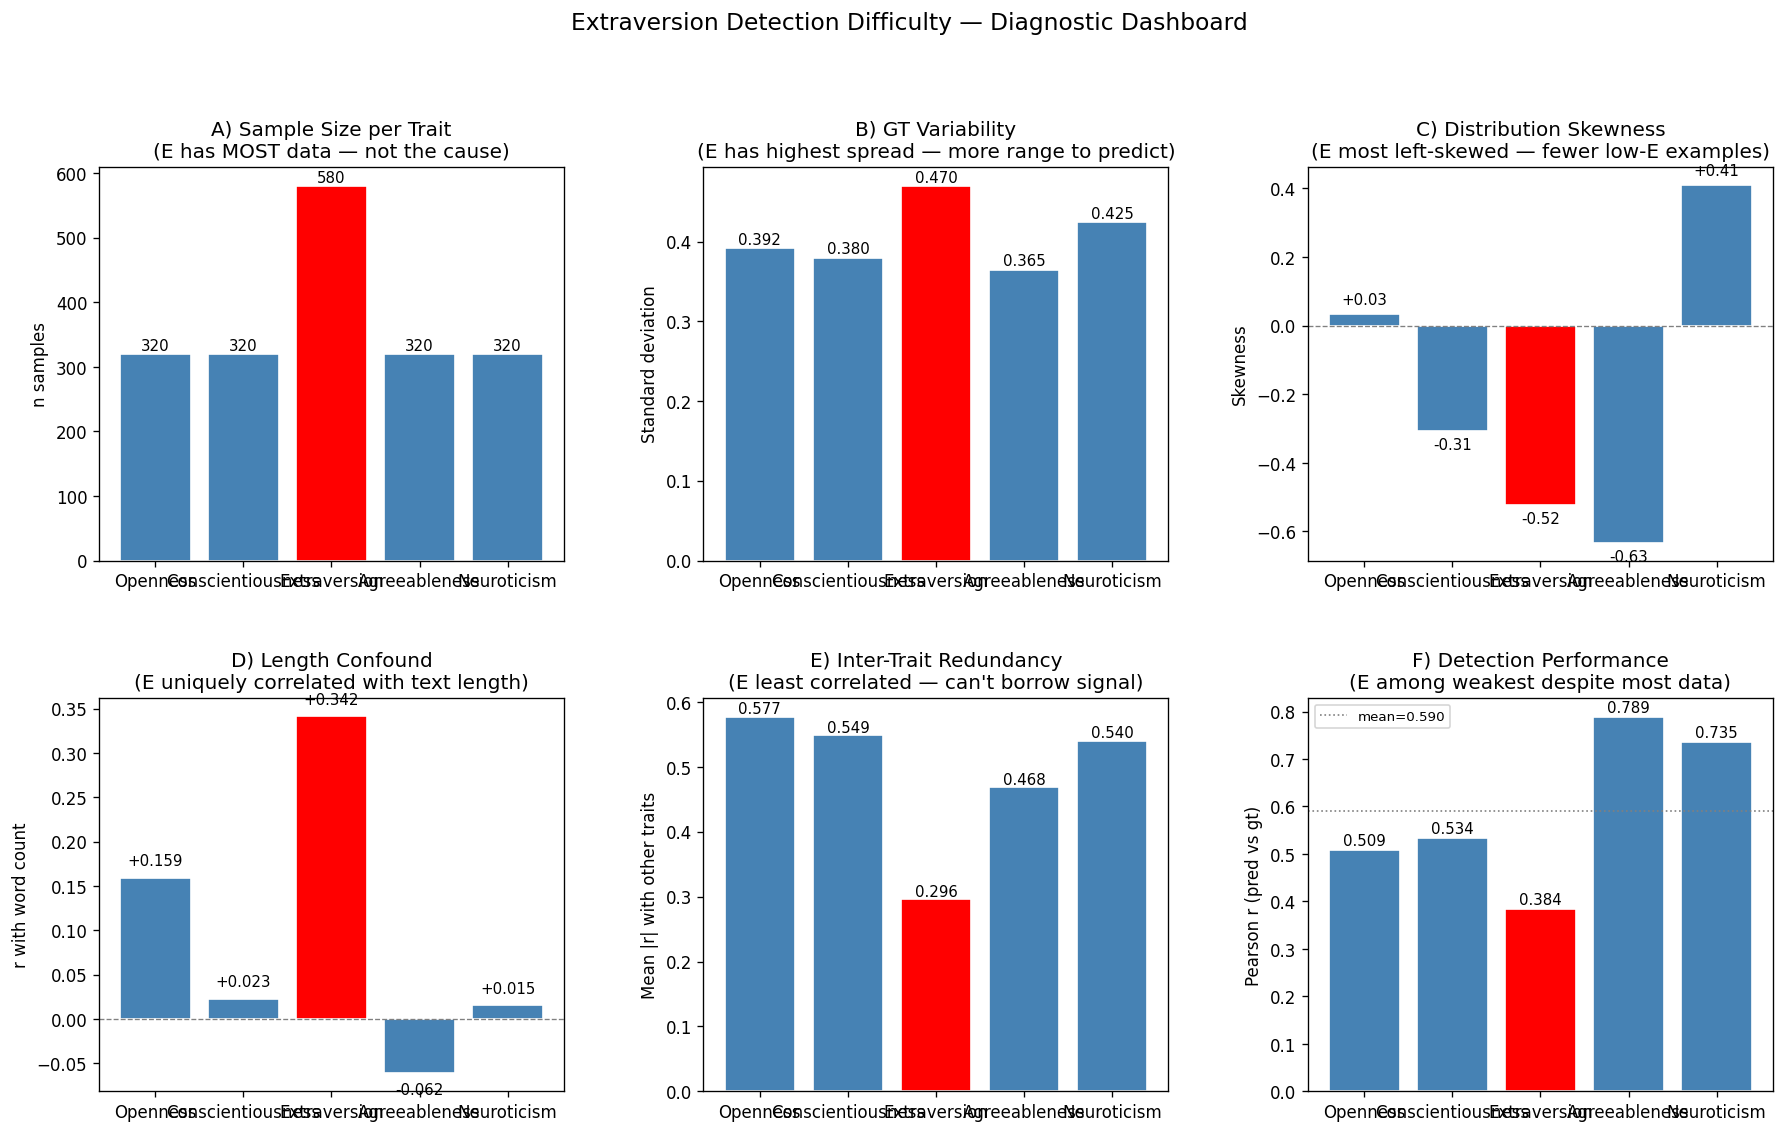

In [29]:
# --- Finding 5: Detection difficulty dashboard ---
fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 3, hspace=0.35, wspace=0.3)

# Panel A: Sample size per trait
ax = fig.add_subplot(gs[0, 0])
sizes = [df[f"gt_{t}"].notna().sum() for t in TRAITS]
colors = ["red" if t == "E" else "steelblue" for t in TRAITS]
bars = ax.bar([TRAIT_NAMES[t] for t in TRAITS], sizes, color=colors, edgecolor="white")
for bar, s in zip(bars, sizes):
    ax.text(bar.get_x() + bar.get_width()/2, s + 5, str(s), ha="center", fontsize=9)
ax.set_ylabel("n samples")
ax.set_title("A) Sample Size per Trait\n(E has MOST data — not the cause)")

# Panel B: GT standard deviation
ax = fig.add_subplot(gs[0, 1])
stds = [df[f"gt_{t}"].dropna().std() for t in TRAITS]
bars = ax.bar([TRAIT_NAMES[t] for t in TRAITS], stds, color=colors, edgecolor="white")
for bar, s in zip(bars, stds):
    ax.text(bar.get_x() + bar.get_width()/2, s + 0.005, f"{s:.3f}", ha="center", fontsize=9)
ax.set_ylabel("Standard deviation")
ax.set_title("B) GT Variability\n(E has highest spread — more range to predict)")

# Panel C: Skewness
ax = fig.add_subplot(gs[0, 2])
skews = [df[f"gt_{t}"].dropna().skew() for t in TRAITS]
bars = ax.bar([TRAIT_NAMES[t] for t in TRAITS], skews, color=colors, edgecolor="white")
ax.axhline(0, color="gray", ls="--", lw=0.8)
for bar, s in zip(bars, skews):
    ax.text(bar.get_x() + bar.get_width()/2, s + 0.02 * np.sign(s), f"{s:+.2f}", ha="center", fontsize=9,
            va="bottom" if s >= 0 else "top")
ax.set_ylabel("Skewness")
ax.set_title("C) Distribution Skewness\n(E most left-skewed — fewer low-E examples)")

# Panel D: Word-count correlation
ax = fig.add_subplot(gs[1, 0])
r_wc = []
for t in TRAITS:
    sub = df.dropna(subset=[f"gt_{t}"])
    r_val, _ = stats.pearsonr(sub["word_count"], sub[f"gt_{t}"])
    r_wc.append(r_val)
bars = ax.bar([TRAIT_NAMES[t] for t in TRAITS], r_wc, color=colors, edgecolor="white")
ax.axhline(0, color="gray", ls="--", lw=0.8)
for bar, rv in zip(bars, r_wc):
    ax.text(bar.get_x() + bar.get_width()/2, rv + 0.01 * np.sign(rv), f"{rv:+.3f}", ha="center", fontsize=9,
            va="bottom" if rv >= 0 else "top")
ax.set_ylabel("r with word count")
ax.set_title("D) Length Confound\n(E uniquely correlated with text length)")

# Panel E: Inter-trait correlation strength (mean |r| with other traits)
ax = fig.add_subplot(gs[1, 1])
full_df = df[df["has_full_ocean"]]
mean_abs_r = []
for t in TRAITS:
    rs = []
    for t2 in TRAITS:
        if t2 == t:
            continue
        sub = full_df.dropna(subset=[f"gt_{t}", f"gt_{t2}"])
        r_val, _ = stats.pearsonr(sub[f"gt_{t}"], sub[f"gt_{t2}"])
        rs.append(abs(r_val))
    mean_abs_r.append(np.mean(rs))
bars = ax.bar([TRAIT_NAMES[t] for t in TRAITS], mean_abs_r, color=colors, edgecolor="white")
for bar, rv in zip(bars, mean_abs_r):
    ax.text(bar.get_x() + bar.get_width()/2, rv + 0.005, f"{rv:.3f}", ha="center", fontsize=9)
ax.set_ylabel("Mean |r| with other traits")
ax.set_title("E) Inter-Trait Redundancy\n(E least correlated — can't borrow signal)")

# Panel F: Prediction accuracy (if results exist)
ax = fig.add_subplot(gs[1, 2])
if pred_rows_all:
    pearson_rs = []
    for t in TRAITS:
        pairs = [(r["detected_ocean"][t], r["ground_truth_ocean"][t])
                 for r in pred_rows_all if t in r.get("ground_truth_ocean", {}) and t in r.get("detected_ocean", {})]
        if pairs:
            p = np.array([x[0] for x in pairs])
            g = np.array([x[1] for x in pairs])
            r_val, _ = stats.pearsonr(p, g)
            pearson_rs.append(r_val)
        else:
            pearson_rs.append(0)
    bars = ax.bar([TRAIT_NAMES[t] for t in TRAITS], pearson_rs, color=colors, edgecolor="white")
    for bar, rv in zip(bars, pearson_rs):
        ax.text(bar.get_x() + bar.get_width()/2, rv + 0.01, f"{rv:.3f}", ha="center", fontsize=9)
    ax.set_ylabel("Pearson r (pred vs gt)")
    ax.set_title("F) Detection Performance\n(E among weakest despite most data)")
    ax.axhline(np.mean(pearson_rs), color="gray", ls=":", lw=1, label=f"mean={np.mean(pearson_rs):.3f}")
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, "No prediction\nresults available", ha="center", va="center", transform=ax.transAxes)
    ax.set_title("F) Detection Performance")

fig.suptitle("Extraversion Detection Difficulty — Diagnostic Dashboard", fontsize=14, y=1.01)
plt.show()

## Summary of Findings

### Dataset Composition
- **580 total samples**: 320 with full OCEAN ground truth, 260 with Extraversion-only ratings
- **12 personality conditions**: `extra_high/low`, `sparky` have E-only; `agree_high/low`, `consc_high/low`, `ems_high/low`, `open_high/low`, `random` have full OCEAN
- The E-only subset (n=260) comes from explicitly manipulated extraversion conditions

### Key Finding: Extraversion detection weakness is NOT caused by data scarcity

| Factor | Extraversion | Other Traits | Verdict |
|--------|-------------|--------------|---------|
| Sample size | n=580 (most) | n=320 each | **Not the cause** |
| GT variability | std=0.470 (highest) | 0.365–0.425 | **Not the cause** |
| GT skewness | -0.522 (most skewed) | -0.633 to +0.409 | **Contributing factor** — fewer low-E samples |
| Length confound | r=+0.342 with word count | r < 0.16 | **Primary confound** — model may use verbosity as E proxy |
| Inter-trait correlation | mean \|r\| = 0.296 (lowest) | 0.376–0.524 | **Contributing** — E is most independent, can't borrow signal |
| Subset distribution shift | E-only mean=+0.303 vs full=+0.178 | N/A | **Contributing** — merged dataset over-represents high-E |

### Prediction Bias Pattern
- The model has a **strong positive bias** for introverted text (low GT-E):
  - GT in [-1.0, -0.5]: bias = **+0.96** (nearly 1 full scale point!)
  - GT in [-0.5, 0.0]: bias = +0.56
  - GT in [+0.5, +1.0]: bias ≈ 0 (accurate)
- The model essentially **cannot detect introversion** — it defaults to predicting moderate-to-high E

### Actionable Implications
1. **Prompt engineering**: Add explicit low-E examples to few-shot, instruct that "short/terse text does not mean high extraversion"
2. **Calibration**: Post-hoc calibration could correct the positive bias
3. **Evaluation**: Report E accuracy separately for low-E vs high-E subgroups
4. **Dataset**: The E-only subset inflates high-E representation — consider stratified evaluation